# 🔄 Sprint Retrospective Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/retro-generator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/retro-generator/demo.ipynb)

> **Retros are unstructured and repetitive.** Feed in the sprint numbers, get structured observations + action items in your team's format — every sprint, in seconds.

**Covers:** sprint metrics → observations → action items → a format (Start/Stop/Continue, 4Ls) → a velocity chart.


## Step 1 — Sprint metrics drive the retro

A good retro isn't invented from memory — it's grounded in what happened: completion rate, velocity change, carryover, bugs, incidents, mood. Encode those and the observations write themselves.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List


@dataclass
class SprintData:
    sprint_name: str
    planned_points: int
    completed_points: int
    carryover_items: int
    bugs_found: int
    incidents: int
    team_mood: float
    prev_completed_points: int = 0
    notes: List[str] = field(default_factory=list)

    @property
    def completion_rate(self):
        return self.completed_points / self.planned_points if self.planned_points else 0

    @property
    def velocity_delta(self):
        return self.completed_points - self.prev_completed_points


sprint = SprintData("Sprint 24", 40, 31, 4, 6, 1, 3.2, prev_completed_points=35,
                    notes=["New CI pipeline saved review time."])
print(f"Completion {sprint.completion_rate:.0%} | velocity {sprint.velocity_delta:+d} | mood {sprint.team_mood}/5")


Completion 78% | velocity -4 | mood 3.2/5


## Step 2 — Metrics → observations → action items

Rules translate each metric into a "went well" or "to improve" note, then into a concrete action. Low completion → cut commitment; heavy carryover → smaller stories; incidents → post-mortems. Structured, not vibes.


In [2]:
def observations(d: SprintData) -> Dict[str, List[str]]:
    good, bad = [], []
    cr = d.completion_rate
    (good if cr >= 0.9 else bad if cr < 0.7 else good).append(f"Completed {cr:.0%} of planned points.")
    if d.velocity_delta < 0: bad.append(f"Velocity down {abs(d.velocity_delta)} pts vs last sprint.")
    elif d.velocity_delta > 0: good.append(f"Velocity up {d.velocity_delta} pts.")
    if d.carryover_items >= 3: bad.append(f"{d.carryover_items} carryover items - over-committed.")
    if d.bugs_found >= 5: bad.append(f"{d.bugs_found} bugs - tighten quality gate.")
    if d.incidents: bad.append(f"{d.incidents} incident(s) - needs follow-up.")
    if d.team_mood <= 2.5: bad.append(f"Mood low ({d.team_mood}/5).")
    elif d.team_mood >= 4: good.append(f"Mood high ({d.team_mood}/5).")
    return {"good": good, "bad": bad}


def actions(d: SprintData) -> List[str]:
    a = []
    if d.completion_rate < 0.7: a.append("Cut next commitment ~15%, re-estimate biggest stories.")
    if d.carryover_items >= 3: a.append("Split carryover into smaller stories before pulling in.")
    if d.bugs_found >= 5: a.append("Add definition-of-done checklist + mid-sprint bug triage.")
    if d.incidents: a.append("Blameless post-incident review per incident.")
    return a or ["Keep cadence; try one small process experiment."]


obs = observations(sprint)
print("WENT WELL:", obs["good"])
print("TO IMPROVE:", obs["bad"])
print("ACTIONS:", actions(sprint))


WENT WELL: ['Completed 78% of planned points.']
TO IMPROVE: ['Velocity down 4 pts vs last sprint.', '4 carryover items - over-committed.', '6 bugs - tighten quality gate.', '1 incident(s) - needs follow-up.']
ACTIONS: ['Split carryover into smaller stories before pulling in.', 'Add definition-of-done checklist + mid-sprint bug triage.', 'Blameless post-incident review per incident.']


## Step 3 — Visualize plan vs. done vs. velocity

The picture that opens the retro meeting.


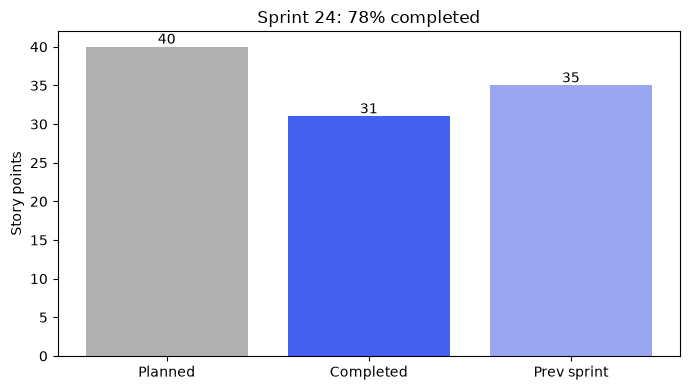

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
bars = ["Planned", "Completed", "Prev sprint"]
vals = [sprint.planned_points, sprint.completed_points, sprint.prev_completed_points]
colors = ["#b0b0b0", "#4361ee", "#9aa7f0"]
b = ax.bar(bars, vals, color=colors)
for bar, v in zip(b, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4, str(v), ha="center")
ax.set_ylabel("Story points")
ax.set_title(f"{sprint.sprint_name}: {sprint.completion_rate:.0%} completed")
plt.tight_layout()
plt.savefig("retro_velocity.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- **Metrics make retros honest.** The same numbers every sprint → consistent, comparable observations.
- **Every observation gets an action.** A retro without action items is a vent session.
- **Formats are just views.** Start/Stop/Continue, 4Ls, went-well/improve — same observations, different frame.

The full app takes the metrics via sliders, emits a downloadable `retro.md`, and (with a Claude key) adds an encouraging narrative summary.


## Try your own sprint

Plug in your real numbers and re-run. The rules are simple on purpose — tune the thresholds to your team's norms.


In [4]:
# mine = SprintData("Sprint 25", planned_points=45, completed_points=44, carryover_items=1,
#                   bugs_found=2, incidents=0, team_mood=4.3, prev_completed_points=31)
# print(observations(mine)); print(actions(mine))


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 54, Mini SaaS Products.

Streamlit version (sliders, format picker, downloadable retro, Claude narrative):
```bash
pip install -r requirements.txt
streamlit run app.py
```
